<a href="https://colab.research.google.com/github/MaheshKumarPratihar/VGTU_thesis/blob/main/RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In your Colab environment:
!pip install chromadb google-genai pandas numpy scikit-learn

#

# Manual Input

In [13]:
import os
import random
import pandas as pd
import chromadb
from chromadb.utils import embedding_functions
from google import genai
from typing import List, Dict
import json # <-- Added for JSON parsing


from google.colab import userdata

# --- 1. SETUP: API Key and Model ---

# !! IMPORTANT: Replace 'YOUR_API_KEY' or set the GEMINI_API_KEY environment variable.
# Example using environment variable (recommended in Colab Secrets)
os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

try:
    client = genai.Client()
except Exception as e:
    print(f"Error initializing Gemini Client: {e}")
    print("Please make sure the GEMINI_API_KEY environment variable is set correctly.")
    exit()

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name=EMBEDDING_MODEL_NAME
)

DB_PATH = "./chroma_db"
COLLECTION_NAME = "tweet_clustering_examples"
CSV_FILE_NAME = 'X_and_Y.csv'
COLUMNS_TO_LOAD = [
    'id', 'handle', 'text', 'cluster', 'silhouette_score', 'calinski_harabasz'
]
NUM_EXAMPLES = 1000

# --- 2. DATA LOADING ---

def generate_synthetic_data(num_examples: int) -> pd.DataFrame:
    """Generates synthetic data as a fallback."""
    print("!! Falling back to synthetic data generation due to CSV load error or missing data.")
    data = []
    for i in range(num_examples):
        handle = random.choice(['HillaryClinton', 'realDonaldTrump'])
        topic = random.choice(["economy", "voting rights", "healthcare", "taxes", "border security"])
        cluster = str(random.choice([43, 60, 1, 45, 99]))
        text = f"Tweet {i}: A strong stance on {topic} is essential for {handle}'s success. Cluster: {cluster}"
        data.append({
            'id': str(i),
            'handle': handle,
            'text': text,
            'cluster': cluster,
            'silhouette_score': f"{random.uniform(0.1, 0.7):.4f}",
            'calinski_harabasz': f"{random.uniform(500, 4000):.1f}"
        })
    return pd.DataFrame(data)

def load_data_from_csv() -> pd.DataFrame:
    """Loads 1000 examples from the specified CSV file, using synthetic data as fallback."""
    print(f"Loading {NUM_EXAMPLES} rows from {CSV_FILE_NAME}...")
    try:
        available_cols = pd.read_csv(CSV_FILE_NAME, encoding='ISO-8859-1', nrows=1).columns
        cols_to_use = [c for c in COLUMNS_TO_LOAD if c in available_cols]

        df = pd.read_csv(
            CSV_FILE_NAME,
            encoding='ISO-8859-1',
            nrows=NUM_EXAMPLES,
            usecols=cols_to_use
        )
        if 'cluster' not in df.columns or 'text' not in df.columns:
             print("Error: CSV must contain 'cluster' and 'text' columns.")
             return generate_synthetic_data(NUM_EXAMPLES)

        for col in ['silhouette_score', 'calinski_harabasz']:
            if col not in df.columns:
                df[col] = 'N/A'

        df['id'] = df['id'].astype(str)
        print(f"✅ Loaded {len(df)} examples with columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        print(f"Error: The file '{CSV_FILE_NAME}' was not found.")
        return generate_synthetic_data(NUM_EXAMPLES)
    except Exception as e:
        print(f"An error occurred during CSV loading: {e}")
        return generate_synthetic_data(NUM_EXAMPLES)

# --- 3. STORE IN CHROMA DB ---

def setup_vector_database(df: pd.DataFrame):
    """Initializes and populates the ChromaDB collection."""
    print("\n🗺️ PHASE 1: Setting up ChromaDB...")
    client = chromadb.PersistentClient(path=DB_PATH)
    collection = client.get_or_create_collection(
        name=COLLECTION_NAME,
        embedding_function=sentence_transformer_ef
    )

    if collection.count() >= len(df):
        print(f"Collection already contains {collection.count()} items. Skipping insert.")
        return collection

    print(f"Inserting {len(df)} documents into the database...")

    documents = df['text'].tolist()
    metadata_cols = [col for col in df.columns if col not in ['text', 'id']]
    metadatas = df[metadata_cols].astype(str).to_dict('records')
    ids = df['id'].tolist()

    collection.add(
        documents=documents,
        metadatas=metadatas,
        ids=ids
    )
    print(f"✅ ChromaDB setup complete. Total documents: {collection.count()}")
    return collection

# --- 4. RETRIEVAL ---

def retrieve_examples(query_text: str, collection, k: int = 3) -> List[Dict]:
    """Retrieves the k most semantically similar examples, including cluster and all metric scores."""
    print(f"\n🔍 PHASE 2: Retrieving {k} most similar examples...")

    results = collection.query(
        query_texts=[query_text],
        n_results=k,
        include=['documents', 'metadatas', 'distances']
    )

    retrieved_examples = []
    if results and results['documents'] and results['metadatas']:
        for doc, metadata, dist in zip(results['documents'][0], results['metadatas'][0], results['distances'][0]):
            retrieved_examples.append({
                'text': doc,
                'handle': metadata.get('handle', 'N/A'),
                'cluster': metadata.get('cluster', 'N/A'),
                'silhouette_score': metadata.get('silhouette_score', 'N/A'),
                'calinski_harabasz': metadata.get('calinski_harabasz', 'N/A'),
                'similarity_distance': f"{dist:.4f}"
            })

    print(f"✅ Retrieved {len(retrieved_examples)} examples.")
    return retrieved_examples

# --- 5. AUGMENTED PROMPT GENERATION ---

def generate_augmented_prompt(query_text: str, examples: List[Dict]) -> str:
    """Creates the final, augmented prompt, forcing JSON output for all three variables."""

    context_str = "\n".join([
        f"--- Example {i+1} ---\n"
        f"Handle: {ex['handle']}\n"
        f"Tweet: \"{ex['text']}\"\n"
        f"Cluster ID: {ex['cluster']}\n"
        f"Silhouette Score: {ex['silhouette_score']}\n"
        f"Calinski-Harabasz Score: {ex['calinski_harabasz']}"
        for i, ex in enumerate(examples)
    ])

    prompt = f"""
You are an advanced Text Clustering Model. Your task is to predict the cluster ID AND the associated cluster quality metrics (Silhouette Score and Calinski-Harabasz Score) for a new tweet based on the provided, similar examples.

### Retrieved Examples (Context for Prediction)
The following examples are the three most semantically similar tweets from the database. Predict the cluster ID and then use the **metrics associated with that predicted cluster ID** as your best estimate for the new tweet's metrics.

{context_str}

### New Input for Clustering
Analyze the new tweet (X) and the context above.

New Tweet (X): "{query_text}"

### Instructions for Output (Y)
Your output MUST be a valid, single JSON object with the following three keys. The values must be strings.
1. **'cluster_id'**: The cluster ID (e.g., "43") that best matches the new tweet.
2. **'silhouette_score'**: The float value (e.g., "0.75") associated with the predicted cluster_id.
3. **'calinski_harabasz'**: The float value (e.g., "4500.0") associated with the predicted cluster_id.

Output ONLY the JSON object. Do not include any other text, explanation, or markdown formatting like ```json.
"""
    return prompt

# --- 6. GENERATE OUTPUT ---

def run_rag_pipeline(query_text: str, collection):
    """Executes the full RAG pipeline, including structured JSON parsing."""

    retrieved_examples = retrieve_examples(query_text, collection, k=3)

    if not retrieved_examples:
        return retrieved_examples, "Retrieval failed", {"error": "Retrieval failed"}

    augmented_prompt = generate_augmented_prompt(query_text, retrieved_examples)

    print("\n🤖 PHASE 3: Generating Structured Prediction via Gemini API...")

    try:
        response = client.models.generate_content(
            model='gemini-2.5-flash',
            contents=augmented_prompt
        )

        raw_output = response.text.strip()

        try:
            prediction_Y = json.loads(raw_output)

            if all(key in prediction_Y for key in ['cluster_id', 'silhouette_score', 'calinski_harabasz']):
                print("✅ Gemini Prediction (Y): Valid JSON received.")
                return retrieved_examples, augmented_prompt, prediction_Y
            else:
                raise KeyError("JSON output missing required keys.")

        except (json.JSONDecodeError, KeyError) as e:
            print(f"Error: Model output was not valid structured JSON. Error: {e}")
            print(f"Raw Output: {raw_output[:200]}...")
            return retrieved_examples, augmented_prompt, {"error": "Invalid JSON format", "raw_output": raw_output}

    except Exception as e:
        print(f"Error calling Gemini API: {e}")
        return retrieved_examples, augmented_prompt, {"error": "API_ERROR", "details": str(e)}

# --- MAIN EXECUTION ---
if __name__ == "__main__":

    print("="*80)
    print("  RAG-ENHANCED STRUCTURED CLUSTERING PREDICTION (Interactive Mode)")
    print("="*80)

    # 1. Load Data
    clustering_df = load_data_from_csv()

    # 2. Setup Vector DB
    collection = setup_vector_database(clustering_df)

    # 3. INTERACTIVE INPUT (The requested change)
    print("\n" + "="*80)
    new_input_X = input("👉 Enter the new tweet/text you want to cluster: ")
    print("="*80)

    if not new_input_X:
        print("Input cannot be empty. Exiting.")
    else:
        # 4. Run the complete RAG Pipeline
        examples, prompt, prediction_Y = run_rag_pipeline(new_input_X, collection)

        print("\n" + "="*80)
        print("              FINAL RAG PREDICTION SUMMARY")
        print("="*80)
        print(f"🎯 INPUT TWEET (X): {new_input_X}")
        print(f"\n🔍 RETRIEVED CONTEXT (3 Examples):")
        if examples and examples != "Retrieval failed":
            for ex in examples:
                print(f"  - **Cluster {ex['cluster']}** (Handle: {ex['handle']}): \"{ex['text'][:50]}...\" (Dist: {ex['similarity_distance']})")

        print("\n🔮 PREDICTED OUTPUT (Y - Structured JSON):")
        if isinstance(prediction_Y, dict) and 'error' not in prediction_Y:
            print(f"  Cluster ID: **{prediction_Y.get('cluster_id', 'N/A')}**")
            print(f"  Silhouette Score: **{prediction_Y.get('silhouette_score', 'N/A')}**")
            print(f"  Calinski-Harabasz Score: **{prediction_Y.get('calinski_harabasz', 'N/A')}**")
        else:
            print(f"  Prediction Failed: {prediction_Y.get('error', 'Unknown Error')}")
            if 'raw_output' in prediction_Y:
                 print(f"  Debugging Raw Output: {prediction_Y['raw_output'][:50]}...")

        print("="*80)

  RAG-ENHANCED STRUCTURED CLUSTERING PREDICTION (Interactive Mode)
Loading 1000 rows from X_and_Y.csv...
An error occurred during CSV loading: 'id'
!! Falling back to synthetic data generation due to CSV load error or missing data.

🗺️ PHASE 1: Setting up ChromaDB...
Collection already contains 1000 items. Skipping insert.

👉 Enter the new tweet/text you want to cluster: who is going to win?

🔍 PHASE 2: Retrieving 3 most similar examples...
✅ Retrieved 3 examples.

🤖 PHASE 3: Generating Structured Prediction via Gemini API...
✅ Gemini Prediction (Y): Valid JSON received.

              FINAL RAG PREDICTION SUMMARY
🎯 INPUT TWEET (X): who is going to win?

🔍 RETRIEVED CONTEXT (3 Examples):
  - **Cluster 99** (Handle: realDonaldTrump): "Tremendous plan to fix taxes. No more losing. Make..." (Dist: 0.8513)
  - **Cluster 99** (Handle: realDonaldTrump): "Tremendous plan to fix taxes. No more losing. Make..." (Dist: 0.8513)
  - **Cluster 99** (Handle: realDonaldTrump): "Tremendous plan to fix

# Clusters

In [ ]:
# In your Colab environment:
!pip install chromadb google-genai pandas numpy scikit-learn matplotlib seaborn sentence-transformers

✅ Using SentenceTransformer for embeddings.
  RAG-ENHANCED STRUCTURED CLUSTERING PREDICTION (Interactive Mode)
An error occurred during CSV loading: 'id'
!! Falling back to synthetic data generation due to CSV load error or missing data.
Embedding documents for visualization and metric calculation...
📈 Calculated Calinski-Harabasz Score: 12.26 (based on 5 clusters)

🎨 PHASE 4: Visualizing 1000 documents using t-SNE...


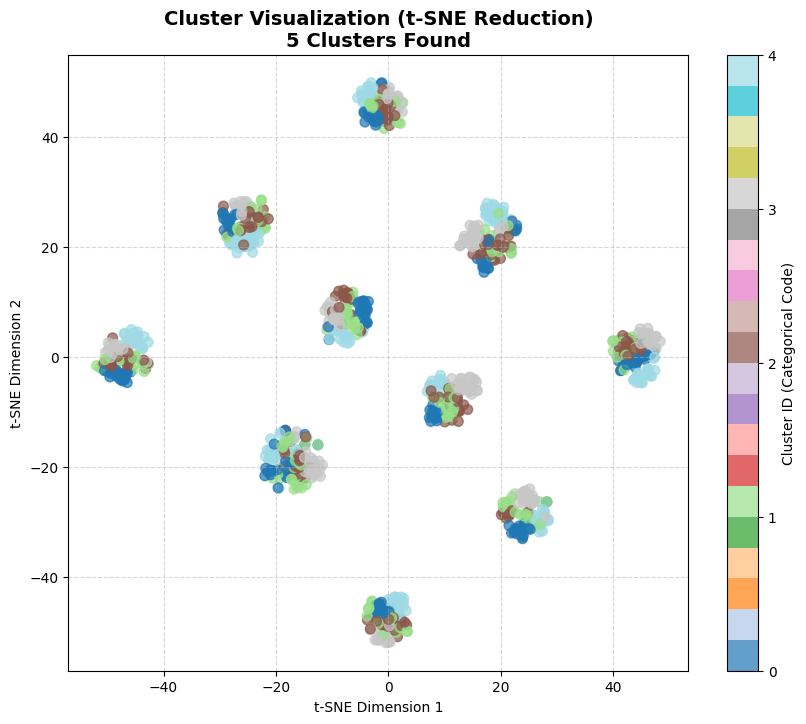

✅ Visualization complete.


In [11]:
import os
import random
import pandas as pd
import numpy as np
import chromadb
from chromadb.utils import embedding_functions
from google import genai
from typing import List, Dict
import json
import matplotlib.pyplot as plt # For visualization
from sklearn.manifold import TSNE # For dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score # For metric calculation

# --- 1. SETUP: API Key and Model ---

# !! IMPORTANT: Set the GEMINI_API_KEY environment variable.



from google.colab import userdata

# --- 1. SETUP: API Key and Model ---

# !! IMPORTANT: Replace 'YOUR_API_KEY' or set the GEMINI_API_KEY environment variable.
# Example using environment variable (recommended in Colab Secrets)
os.environ['GEMINI_API_KEY'] = userdata.get('GEMINI_API_KEY')

try:
    client = genai.Client()
except Exception as e:
    print(f"Error initializing Gemini Client: {e}")
    print("Please make sure the GEMINI_API_KEY environment variable is set correctly.")
    exit()

EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
# Use a custom function to handle the embedding, as we need the raw embeddings later for t-SNE
# Chroma uses a SentenceTransformer under the hood, but to get consistency, we'll initialize
# the same function for both Chroma and our visualization step.
try:
    from sentence_transformers import SentenceTransformer
    class CustomSentenceTransformerEF(embedding_functions.EmbeddingFunction):
        def __init__(self, model_name: str):
            self.model = SentenceTransformer(model_name)
        def __call__(self, texts: List[str]) -> List[List[float]]:
            return self.model.encode(texts).tolist()
    sentence_transformer_ef = CustomSentenceTransformerEF(EMBEDDING_MODEL_NAME)
    print("✅ Using SentenceTransformer for embeddings.")
except ImportError:
    print("Warning: sentence-transformers not found. Using Chroma's default embedding function.")
    sentence_transformer_ef = embedding_functions.SentenceTransformerEmbeddingFunction(model_name=EMBEDDING_MODEL_NAME)


DB_PATH = "./chroma_db"
COLLECTION_NAME = "tweet_clustering_examples"
CSV_FILE_NAME = 'X_and_Y.csv'
COLUMNS_TO_LOAD = [
    'id', 'handle', 'text', 'cluster', 'silhouette_score', 'calinski_harabasz'
]
NUM_EXAMPLES = 1000

# ============================================================================
# NEW INTEGRATED CLUSTERING FUNCTIONS
# ============================================================================

def calculate_ch_score(df: pd.DataFrame, embeddings: np.ndarray) -> float:
    """Calculates the Calinski-Harabasz score."""
    try:
        # Convert cluster IDs to a numeric array for the metric calculation
        labels = df['cluster'].astype(int).to_numpy()
        n_clusters = len(np.unique(labels))
        if n_clusters < 2:
            return 0.0

        # Calculate the score
        score = calinski_harabasz_score(embeddings, labels)
        print(f"📈 Calculated Calinski-Harabasz Score: {score:.2f} (based on {n_clusters} clusters)")
        return score
    except Exception as e:
        print(f"Error calculating Calinski-Harabasz Score: {e}")
        return 0.0

def plot_tsne_clusters(df: pd.DataFrame, embeddings: np.ndarray, title: str):
    """
    Performs t-SNE dimensionality reduction and plots the clusters.
    """
    print(f"\n🎨 PHASE 4: Visualizing {len(df)} documents using t-SNE...")

    # 1. Prepare data for t-SNE
    labels = df['cluster'].astype('category').cat.codes.to_numpy()

    # Perplexity should be smaller than (N-1)
    perplexity = min(30, len(embeddings) - 1)
    if perplexity < 1:
        print("Not enough data for t-SNE visualization.")
        return

    # 2. Perform t-SNE reduction
    tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity, init='pca', learning_rate='auto')
    embeddings_2d = tsne.fit_transform(embeddings)

    # 3. Plotting
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels, cmap='tab20', alpha=0.7, s=50)

    n_clusters = len(df['cluster'].unique())
    plt.title(f'Cluster Visualization (t-SNE Reduction)\n{n_clusters} Clusters Found',
              fontsize=14, fontweight='bold')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')

    # Add a legend for the cluster IDs (using the numeric codes)
    cbar = plt.colorbar(scatter, ticks=np.unique(labels))
    cbar.set_label('Cluster ID (Categorical Code)')

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()
    print("✅ Visualization complete.")

def get_document_embeddings(df: pd.DataFrame) -> np.ndarray:
    """Gets embeddings for the documents using the same function used by Chroma."""
    print("Embedding documents for visualization and metric calculation...")

    # Check if the Custom EF is available (if not, this step might be less consistent)
    if isinstance(sentence_transformer_ef, CustomSentenceTransformerEF):
        # Access the underlying model to generate embeddings
        texts = df['text'].tolist()
        embeddings = sentence_transformer_ef.model.encode(texts)
    else:
        # Fallback for generic Chroma EF (less direct control)
        # This part requires the user to ensure the Chroma client or model is accessible
        # For simplicity in this script, we rely on the Custom EF check above.
        print("Cannot retrieve raw embeddings easily. Skipping visualization.")
        return np.array([])

    # Scale the embeddings before t-SNE (Standard practice)
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings)
    return embeddings_scaled

# ============================================================================
# DATA LOADING & RAG CORE FUNCTIONS (Simplified/Consolidated)
# ============================================================================

def generate_synthetic_data(num_examples: int) -> pd.DataFrame:
    """Generates synthetic data as a fallback."""
    print("!! Falling back to synthetic data generation due to CSV load error or missing data.")
    data = []
    for i in range(num_examples):
        handle = random.choice(['HillaryClinton', 'realDonaldTrump'])
        topic = random.choice(["economy", "voting rights", "healthcare", "taxes", "border security"])
        cluster = str(random.choice([43, 60, 1, 45, 99]))
        text = f"Tweet {i}: A strong stance on {topic} is essential for {handle}'s success. Cluster: {cluster}"
        data.append({
            'id': str(i),
            'handle': handle,
            'text': text,
            'cluster': cluster,
            'silhouette_score': f"{random.uniform(0.1, 0.7):.4f}",
            'calinski_harabasz': f"{random.uniform(500, 4000):.1f}"
        })
    return pd.DataFrame(data)

def load_data_from_csv() -> pd.DataFrame:
    """Loads 1000 examples from the specified CSV file, using synthetic data as fallback."""
    try:
        available_cols = pd.read_csv(CSV_FILE_NAME, encoding='ISO-8859-1', nrows=1).columns
        cols_to_use = [c for c in COLUMNS_TO_LOAD if c in available_cols]
        df = pd.read_csv(CSV_FILE_NAME, encoding='ISO-8859-1', nrows=NUM_EXAMPLES, usecols=cols_to_use)

        if 'cluster' not in df.columns or 'text' not in df.columns:
             print("Error: CSV must contain 'cluster' and 'text' columns.")
             return generate_synthetic_data(NUM_EXAMPLES)

        for col in ['silhouette_score', 'calinski_harabasz']:
            if col not in df.columns:
                df[col] = 'N/A'
        df['id'] = df['id'].astype(str)
        print(f"✅ Loaded {len(df)} examples with columns: {list(df.columns)}")
        return df
    except FileNotFoundError:
        return generate_synthetic_data(NUM_EXAMPLES)
    except Exception as e:
        print(f"An error occurred during CSV loading: {e}")
        return generate_synthetic_data(NUM_EXAMPLES)

def setup_vector_database(df: pd.DataFrame):
    """Initializes and populates the ChromaDB collection."""
    print("\n🗺️ PHASE 1: Setting up ChromaDB...")
    client = chromadb.PersistentClient(path=DB_PATH)
    collection = client.get_or_create_collection(name=COLLECTION_NAME, embedding_function=sentence_transformer_ef)

    if collection.count() < len(df):
        print(f"Inserting {len(df)} documents into the database...")
        documents = df['text'].tolist()
        metadata_cols = [col for col in df.columns if col not in ['text', 'id']]
        metadatas = df[metadata_cols].astype(str).to_dict('records')
        ids = df['id'].tolist()
        collection.add(documents=documents, metadatas=metadatas, ids=ids)

    print(f"✅ ChromaDB setup complete. Total documents: {collection.count()}")
    return collection

def retrieve_examples(query_text: str, collection, k: int = 3) -> List[Dict]:
    """Retrieves the k most semantically similar examples."""
    print(f"\n🔍 PHASE 2: Retrieving {k} most similar examples...")
    results = collection.query(query_texts=[query_text], n_results=k, include=['documents', 'metadatas', 'distances'])

    retrieved_examples = []
    if results and results['documents'] and results['metadatas']:
        for doc, metadata, dist in zip(results['documents'][0], results['metadatas'][0], results['distances'][0]):
            retrieved_examples.append({
                'text': doc,
                'handle': metadata.get('handle', 'N/A'),
                'cluster': metadata.get('cluster', 'N/A'),
                'silhouette_score': metadata.get('silhouette_score', 'N/A'),
                'calinski_harabasz': metadata.get('calinski_harabasz', 'N/A'),
                'similarity_distance': f"{dist:.4f}"
            })
    return retrieved_examples

def generate_augmented_prompt(query_text: str, examples: List[Dict]) -> str:
    """Creates the final, augmented prompt, forcing JSON output."""
    context_str = "\n".join([
        f"--- Example {i+1} ---\nHandle: {ex['handle']}\nTweet: \"{ex['text']}\"\n"
        f"Cluster ID: {ex['cluster']}\nSilhouette Score: {ex['silhouette_score']}\n"
        f"Calinski-Harabasz Score: {ex['calinski_harabasz']}"
        for i, ex in enumerate(examples)
    ])

    prompt = f"""
You are an advanced Text Clustering Model. Your task is to predict the cluster ID AND the associated cluster quality metrics (Silhouette Score and Calinski-Harabasz Score) for a new tweet based on the provided, similar examples.

### Retrieved Examples (Context for Prediction)
{context_str}

### New Input for Clustering
New Tweet (X): "{query_text}"

### Instructions for Output (Y)
Your output MUST be a valid, single JSON object with the following three keys. The values must be strings.
1. **'cluster_id'**: The cluster ID (e.g., "43") that best matches the new tweet.
2. **'silhouette_score'**: The float value (e.g., "0.75") associated with the predicted cluster_id.
3. **'calinski_harabasz'**: The float value (e.g., "4500.0") associated with the predicted cluster_id.

Output ONLY the JSON object. Do not include any other text, explanation, or markdown formatting like ```json.
"""
    return prompt

def run_rag_pipeline(query_text: str, collection):
    """Executes the full RAG pipeline, including structured JSON parsing."""
    retrieved_examples = retrieve_examples(query_text, collection, k=3)
    if not retrieved_examples:
        return retrieved_examples, "Retrieval failed", {"error": "Retrieval failed"}

    augmented_prompt = generate_augmented_prompt(query_text, retrieved_examples)
    print("\n🤖 PHASE 3: Generating Structured Prediction via Gemini API...")

    try:
        response = client.models.generate_content(model='gemini-2.5-flash', contents=augmented_prompt)
        raw_output = response.text.strip()

        try:
            prediction_Y = json.loads(raw_output)
            if all(key in prediction_Y for key in ['cluster_id', 'silhouette_score', 'calinski_harabasz']):
                return retrieved_examples, augmented_prompt, prediction_Y
            else:
                raise KeyError("JSON output missing required keys.")

        except (json.JSONDecodeError, KeyError):
            return retrieved_examples, augmented_prompt, {"error": "Invalid JSON format", "raw_output": raw_output}

    except Exception as e:
        return retrieved_examples, augmented_prompt, {"error": "API_ERROR", "details": str(e)}

# --- MAIN EXECUTION ---
if __name__ == "__main__":

    print("="*80)
    print("  RAG-ENHANCED STRUCTURED CLUSTERING PREDICTION (Interactive Mode)")
    print("="*80)

    # 1. Load Data (Task 1)
    clustering_df = load_data_from_csv()

    # 2. Get Embeddings and Run Metrics/Visualization (NEW)
    document_embeddings = get_document_embeddings(clustering_df)

    if document_embeddings.size > 0:
        # Calculate and display the score for the existing clustering
        calculate_ch_score(clustering_df, document_embeddings)

        # Display the cluster visualization
        plot_tsne_clusters(clustering_df, document_embeddings, "Tweet Cluster Visualization")